In [16]:
import pandas as pd

df = pd.read_csv("presentacion1_resultados.csv")

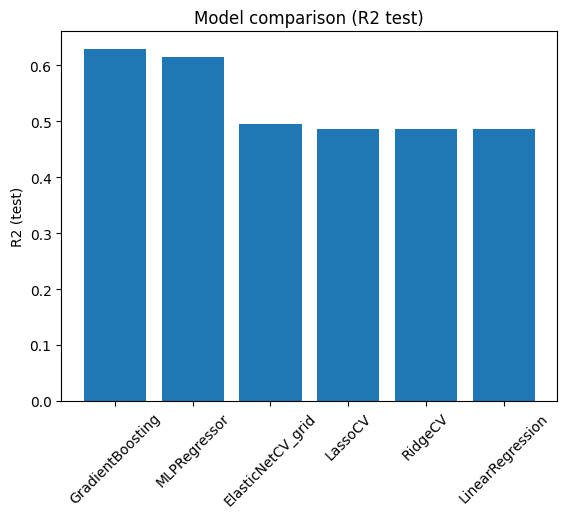

In [17]:
import matplotlib.pyplot as plt
df_sorted = df.sort_values(by='r2_test', ascending=False)
plt.figure()
plt.bar(df_sorted['method'], df_sorted['r2_test'])
plt.xticks(rotation=45)
plt.ylabel("R2 (test)")
plt.title("Model comparison (R2 test)")
plt.show()

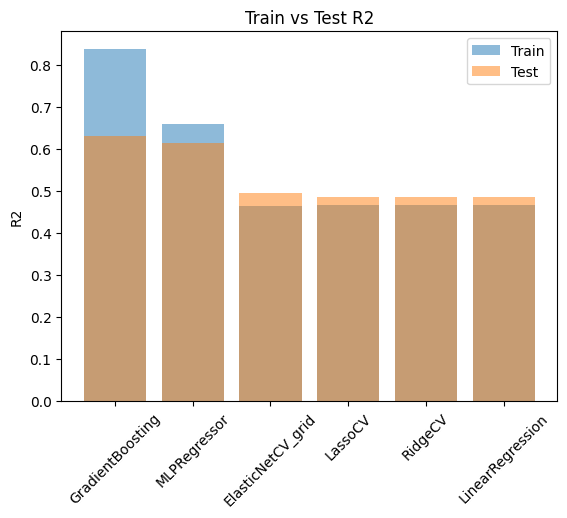

In [18]:
plt.figure()
df_sorted = df.sort_values(by='r2_test', ascending=False)

plt.bar(df_sorted['method'], df_sorted['r2_train'], alpha=0.5, label='Train')
plt.bar(df_sorted['method'], df_sorted['r2_test'], alpha=0.5, label='Test')

plt.xticks(rotation=45)
plt.ylabel("R2")
plt.legend()
plt.title("Train vs Test R2")
plt.show()

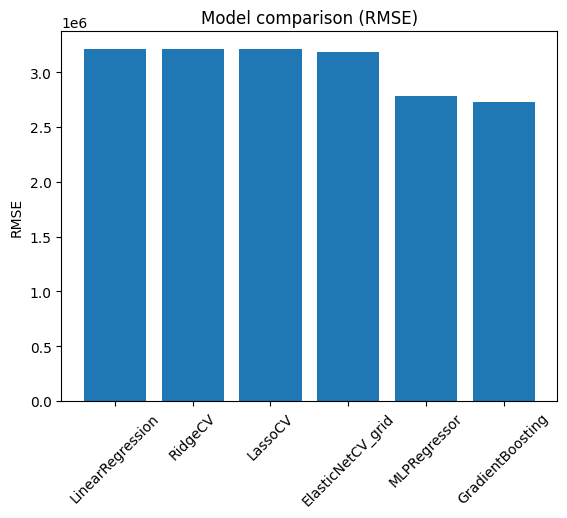

In [19]:
df_sorted = df.sort_values(by='rmse', ascending=False)

plt.figure()
plt.bar(df_sorted['method'], df_sorted['rmse'])
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model comparison (RMSE)")
plt.show()

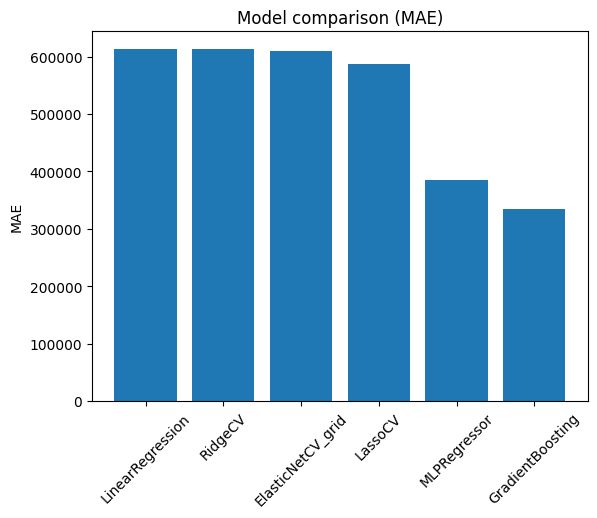

In [20]:
df_sorted = df.sort_values(by='mae', ascending=False)

plt.figure()
plt.bar(df_sorted['method'], df_sorted['mae'])
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("Model comparison (MAE)")
plt.show()

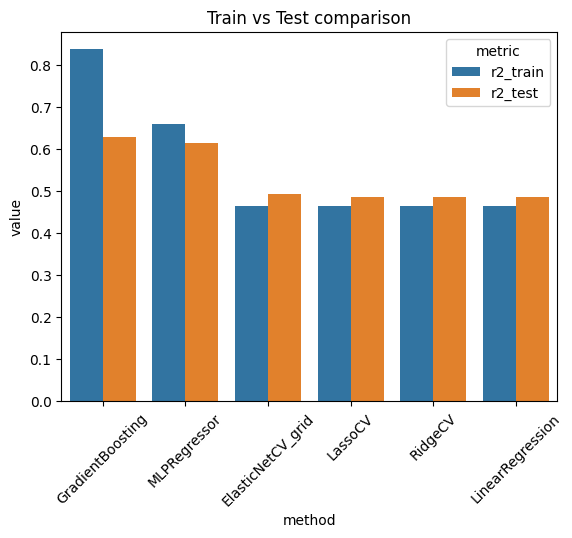

In [21]:
import seaborn as sns
df_sorted = df.sort_values(by='r2_test', ascending=False)

df_melt = df_sorted.melt(id_vars='method', 
                  value_vars=['r2_train', 'r2_test'],
                  var_name='metric', value_name='value')

sns.barplot(data=df_melt, x='method', y='value', hue='metric')
plt.xticks(rotation=45)
plt.title("Train vs Test comparison")
plt.show()

# Porcentaje de mejora respecto al baseline

In [22]:
import pandas as pd

# Get LinearRegression row
baseline = df[df["method"] == "LinearRegression"].iloc[0]

# Baseline metrics
baseline_rmse = baseline["rmse"]
baseline_mae = baseline["mae"]
baseline_r2 = baseline["r2_test"]

# Calculate improvements
df["rmse_reduction_%"] = (
    (baseline_rmse - df["rmse"]) / baseline_rmse
) * 100

df["mae_reduction_%"] = (
    (baseline_mae - df["mae"]) / baseline_mae
) * 100

df["r2_increase_%"] = (
    (df["r2_test"] - baseline_r2) / abs(baseline_r2)
) * 100

# Optional: round results
df = df.round({
    "rmse_reduction_%": 2,
    "mae_reduction_%": 2,
    "r2_increase_%": 2
})

print(df[[
    "method",
    "r2_test",
    "mae",
    "rmse",
    "rmse_reduction_%",
    "mae_reduction_%",
    "r2_increase_%"
]])

              method   r2_test            mae          rmse  rmse_reduction_%  \
0   LinearRegression  0.485584  613012.771484  3.211597e+06              0.00   
1            RidgeCV  0.485599  613005.945981  3.211550e+06              0.00   
2            LassoCV  0.486032  586993.300225  3.210198e+06              0.04   
3  ElasticNetCV_grid  0.494225  609807.316694  3.184506e+06              0.84   
4       MLPRegressor  0.614048  384432.976487  2.781827e+06             13.38   
5   GradientBoosting  0.629044  334765.800654  2.727249e+06             15.08   

   mae_reduction_%  r2_increase_%  
0             0.00           0.00  
1             0.00           0.00  
2             4.24           0.09  
3             0.52           1.78  
4            37.29          26.46  
5            45.39          29.54  
